In [17]:
import allel
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
vcf_path = (
    "/home/tbellagio/scratch/pang/pang_experiment/"
    "pangenomes/set_02_rep1/mapping/seedmix/S1/"
    "S1.snarl_support.vcf"
)

callset = allel.read_vcf(
    vcf_path,
    fields='*'   # read everything explicitly
)


In [3]:
callset

{'samples': array(['S1'], dtype=object),
 'calldata/AD': array([[[ 2,  2, -1, -1]],
 
        [[ 2,  2, -1, -1]],
 
        [[ 0,  2, -1, -1]],
 
        ...,
 
        [[ 1,  0, -1, -1]],
 
        [[ 1,  0, -1, -1]],
 
        [[ 1,  0, -1, -1]]], dtype=int16),
 'calldata/DP': array([[4],
        [4],
        [2],
        ...,
        [1],
        [1],
        [1]], dtype=int16),
 'calldata/GL': array([[[-4.840168, -1.145544, -4.840168]],
 
        [[-6.110149, -2.415525, -6.110149]],
 
        [[-5.395018, -1.399363, -1.098333]],
 
        ...,
 
        [[-1.189331, -0.755355, -2.753182]],
 
        [[-1.189331, -0.755355, -2.753182]],
 
        [[-1.189331, -0.755355, -2.753182]]], dtype=float32),
 'calldata/GP': array([[-1.099016],
        [-1.099016],
        [-1.504111],
        ...,
        [-1.419391],
        [-1.419391],
        [-1.419391]], dtype=float32),
 'calldata/GQ': array([[36],
        [36],
        [ 3],
        ...,
        [ 4],
        [ 4],
        [ 4]], dtyp

In [ ]:
372483

In [6]:
callset['calldata/GT'].shape

(372483, 1, 2)

In [9]:
chr_pos = pd.DataFrame()

In [10]:
chr_pos['chr'] = callset['variants/CHROM']

In [11]:
chr_pos['pos'] = callset['variants/POS']

In [13]:
chr_pos['chr'].value_counts()

chr
Chr1    96645
Chr5    79528
Chr3    72274
Chr2    63032
Chr4    61004
Name: count, dtype: int64

In [ ]:
chr_pos['']

In [18]:
depth = pd.Series(callset['calldata/DP'].flatten())

In [45]:
depth

0         4
1         4
2         2
3         2
4         0
         ..
372478    1
372479    1
372480    1
372481    1
372482    1
Length: 372483, dtype: int32

In [31]:
depth[depth > 500]

28841      1497
96645     15007
96646     18644
96647     19809
96648     19642
          ...  
301792     1529
301793     1540
321550      888
354881     3953
363294      818
Length: 466, dtype: int32

In [23]:
depth.value_counts()

59       9336
56       9188
57       9177
60       9145
58       9087
         ... 
31162       1
31541       1
32057       1
26860       1
818         1
Name: count, Length: 844, dtype: int64

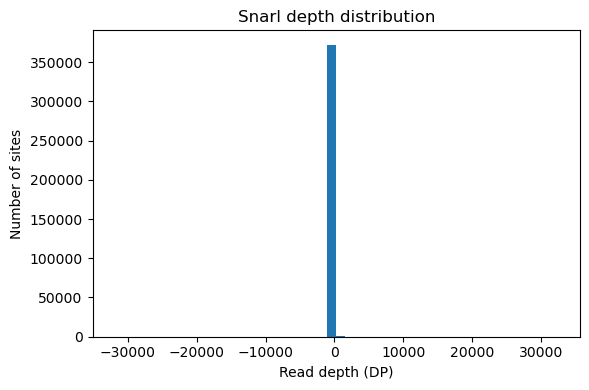

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(depth, bins=50)
plt.xlabel("Read depth (DP)")
plt.ylabel("Number of sites")
plt.title("Snarl depth distribution")
plt.tight_layout()
plt.show()


In [34]:
pd.Series(callset['variants/is_snp']).value_counts(normalize=True)

True     0.786248
False    0.213752
Name: proportion, dtype: float64

In [37]:
pd.Series(callset['variants/numalt']).value_counts()

1    372482
2         1
Name: count, dtype: int64

In [38]:
callset['variants/altlen']

array([[0, 0, 0],
       [0, 0, 0],
       [0, 0, 0],
       ...,
       [0, 0, 0],
       [0, 0, 0],
       [0, 0, 0]], dtype=int32)

In [39]:
path_stats = '/home/tbellagio/scratch/pang/pang_experiment/pangenomes/set_02_rep1/output/tmp/toilwf-ce8de2e373d15fb2ad4e0ea5fe7c55b8/96c8/job/tmp1fv5o3h_'

In [42]:
pd.read_csv(path_stats + '/graph-stats.tsv', sep = '\t', header=None)

,0,1,2
0,Chr1,nodes,1006615
1,Chr1,edges,1361843
2,Chr1,length,35759571
3,Chr2,nodes,672642
4,Chr2,edges,908573
5,Chr2,length,24619423
6,Chr3,nodes,741126
7,Chr3,edges,1001116
8,Chr3,length,29128942
9,Chr4,nodes,682763


In [43]:
pd.read_csv(path_stats + '/path-stats.tsv', sep = '\t', header=None)

,0,1,2
0,Chr1,Zal-1#0#Chr1#0[0-14353194],14353194
1,Chr1,Zal-1#0#Chr1#0[17664447-17822996],158549
2,Chr1,Dog-4#0#Chr1#0[1577-14448568],14446991
3,Chr1,Dog-4#0#Chr1#0[24176189-33823229],9647040
4,Chr1,Zal-1#0#Chr1#0[19608788-32158185],12549397
5,Chr1,Col-0#0#Chr1,32215923
6,Chr1,Zal-1#0#Chr1#0[17881341-19398558],1517217
7,Chr1,Dog-4#0#Chr1#0[19322371-24141961],4819590
8,Chr2,Zal-1#0#seq00000024#0[0-18526],18526
9,Chr2,Dog-4#0#Chr2#0[9526446-23488919],13962473


In [44]:
pd.read_csv(path_stats + '/sample-stats.tsv', sep = '\t', header=None)

,0,1,2
0,Chr1,Col-0#0,32215923
1,Chr1,Dog-4#0,28913621
2,Chr1,Zal-1#0,28578357
3,Chr2,Col-0#0,21785300
4,Chr2,Dog-4#0,18997251
5,Chr2,Zal-1#0,18931990
6,Chr3,Col-0#0,25619339
7,Chr3,Dog-4#0,22203685
8,Chr3,Zal-1#0,21945068
9,Chr4,Col-0#0,20520974
